### Permutation and Random Sampling

In [1]:
import numpy  as np
import pandas as pd

In [60]:
data = pd.read_excel("employee.xlsx")

In [63]:
data.select_dtypes(include=["object"])

,Designation,Department
0,Manager,Accounts
1,Officer,IT
2,Officer,HR
3,Manager,HR
4,Office Boy,Accounts
5,Accountant,NaN
6,Accountant,Accounts
7,Officer,IT
8,Manager,IT
9,Engineer,Production


In [ ]:
numpy = random.permutation
pandas = data.sample

In [19]:
data.sample(4)

,Serial,Emp_ID,Designation,Department,Age,Salary
15,16,1222,Officer,NaN,25.0,NaN
12,13,2156,Engineer,Production,45.0,89000.0
14,15,2912,Officer,IT,31.0,90000.0
11,12,3214,Accountant,Account,49.0,123000.0


In [18]:
np.random.permutation(8)

array([7, 5, 3, 2, 0, 4, 6, 1], dtype=int32)

# Data transformation

## Computing Indicator/Dummy Variables

In [21]:
data.Designation.value_counts()

Designation
Officer       9
Engineer      5
Accountant    5
Manager       3
Office Boy    2
Name: count, dtype: int64

In [23]:
data["category_designatio"]=data.Designation.replace(["Officer","Engineer","Accountant","Manager" ,"Office Boy"],[4,3,2,1,0])

C:\Users\Teacher PC\AppData\Local\Temp\ipykernel_3120\4162256459.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["category_designatio"]=data.Designation.replace(["Officer","Engineer","Accountant","Manager" ,"Office Boy"],[4,3,2,1,0])


In [24]:
data

,Serial,Emp_ID,Designation,Department,Age,Salary,category_designatio
0,1,1101,Manager,Accounts,50.0,200000.0,1
1,2,1107,Officer,IT,30.0,80000.0,4
2,3,1203,Officer,HR,28.0,NaN,4
3,4,1005,Manager,HR,45.0,120000.0,1
4,5,2123,Office Boy,Accounts,27.0,45000.0,0
5,6,2451,Accountant,NaN,34.0,100000.0,2
6,7,1111,Accountant,Accounts,NaN,110000.0,2
7,8,1001,Officer,IT,25.0,75000.0,4
8,9,1234,Manager,IT,23.0,NaN,1
9,10,2156,Engineer,Production,45.0,89000.0,3


In [56]:
df = {
    "emp_id" : [1,2,3,4,5],
    "name" :   ["kamran","ali","kamran","jan",'ali']
}

In [57]:
df =pd.DataFrame(df)
df

,emp_id,name
0,1,kamran
1,2,ali
2,3,kamran
3,4,jan
4,5,ali


In [38]:
df

,emp_id,name
0,1,kamran
1,2,ali
2,3,kamran
3,4,jan
4,5,ali


In [43]:
df = pd.get_dummies(df, dtype=int)

In [44]:
df

,emp_id,name_ali,name_jan,name_kamran
0,1,0,0,1
1,2,1,0,0
2,3,0,0,1
3,4,0,1,0
4,5,1,0,0


In [51]:
data.drop(["category_designatio"], axis=1, inplace=True)

In [53]:
data = pd.get_dummies(data, dtype= int)

In [55]:
data

,Serial,Emp_ID,Age,Salary,Designation_Accountant,Designation_Engineer,Designation_Manager,Designation_Office Boy,Designation_Officer,Department_Account,Department_Accounts,Department_HR,Department_IT,Department_Production
0,1,1101,50.0,200000.0,0,0,1,0,0,0,1,0,0,0
1,2,1107,30.0,80000.0,0,0,0,0,1,0,0,0,1,0
2,3,1203,28.0,NaN,0,0,0,0,1,0,0,1,0,0
3,4,1005,45.0,120000.0,0,0,1,0,0,0,0,1,0,0
4,5,2123,27.0,45000.0,0,0,0,1,0,0,1,0,0,0
5,6,2451,34.0,100000.0,1,0,0,0,0,0,0,0,0,0
6,7,1111,NaN,110000.0,1,0,0,0,0,0,1,0,0,0
7,8,1001,25.0,75000.0,0,0,0,0,1,0,0,0,1,0
8,9,1234,23.0,NaN,0,0,1,0,0,0,0,0,1,0
9,10,2156,45.0,89000.0,0,1,0,0,0,0,0,0,0,1


## Data Wrangling: Join, Combine, and Reshape

In [67]:
df_1=pd.read_excel("test_data.xlsx", sheet_name=0)
df_2=pd.read_excel("test_data.xlsx", sheet_name=1)
df_3=pd.read_excel("test_data.xlsx", sheet_name=2)

In [68]:
df_1

,sales_man_id,sales_man_name,sales_man_city,product_id,manager
0,1,Asad,Karachi,123,Jawed
1,2,Sumair,Lahore,123,Jawed
2,3,Farjad,Karachi,145,Najam
3,4,Hassan,Lahore,567,Najam
4,5,Nasir,Hyderabad,234,Jawed
5,6,Kashif,Hyderabad,234,Faisal
6,7,Sana,Lahore,567,Faisal
7,8,Fatima,Karachi,345,Najam
8,9,Abdullah,Karachi,123,Faisal


In [69]:
df_2

,sales_man_id,sales_man_name,sales_man_city,product_id,manager,Experience
0,1,Asad,Karachi,123,Jawed,2
1,22,Umer,Lahore,123,Jawed,3
2,33,Huzaifa,Karachi,145,Najam,4
3,4,Hassan,Lahore,567,Najam,5
4,55,Hussain,Hyderabad,234,Jawed,6
5,66,Ali,Hyderabad,234,Faisal,7
6,77,Sadaf,Lahore,567,Faisal,8
7,88,Kiran,Karachi,345,Najam,9
8,99,Ali,Karachi,123,Faisal,1
9,101,Asad,Hyderabad,432,Jawed,4


In [71]:
df_3

,sales_man_id,sales_man_name,Region,Sales,Amount
0,1,Asad,A,100,100000
1,2,Sumair,B,300,450000
2,45,Ali,C,234,125000
3,34,Sana,D,231,652000
4,5,Nasir,E,324,145000
5,6,Kashif,F,123,825000
6,7,Sana,G,129,125000
7,8,Fatima,H,345,325600
8,99,Farhan,I,400,895200


## Concatination

In [79]:
pd.concat([df_2, df_1], axis = 0)

,sales_man_id,sales_man_name,sales_man_city,product_id,manager,Experience
0,1,Asad,Karachi,123,Jawed,2.0
1,22,Umer,Lahore,123,Jawed,3.0
2,33,Huzaifa,Karachi,145,Najam,4.0
3,4,Hassan,Lahore,567,Najam,5.0
4,55,Hussain,Hyderabad,234,Jawed,6.0
5,66,Ali,Hyderabad,234,Faisal,7.0
6,77,Sadaf,Lahore,567,Faisal,8.0
7,88,Kiran,Karachi,345,Najam,9.0
8,99,Ali,Karachi,123,Faisal,1.0
9,101,Asad,Hyderabad,432,Jawed,4.0


In [81]:
a={1,2,4,6}
b = {5,1,2,3}

In [82]:
a.union(b)

{1, 2, 3, 4, 5, 6}

In [83]:
a.intersection(b)

{1, 2}

## Merging

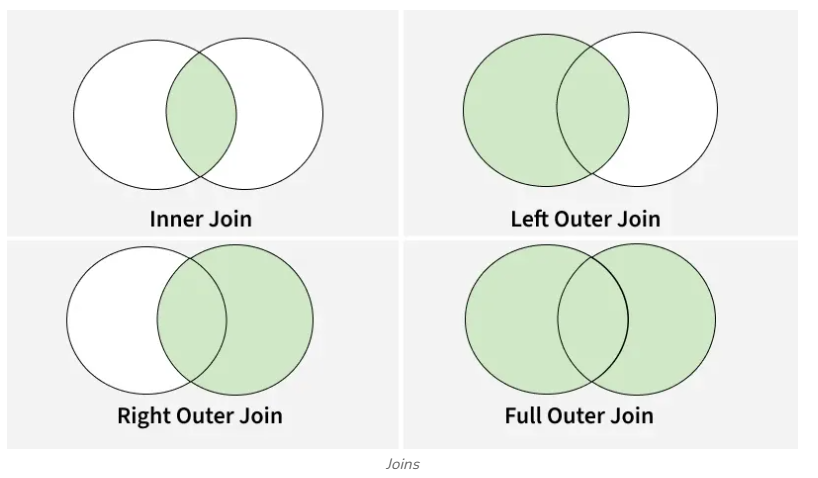

In [90]:
pd.merge(df_1, df_2, on="sales_man_id", how="outer")

,sales_man_id,sales_man_name_x,sales_man_city_x,product_id_x,manager_x,sales_man_name_y,sales_man_city_y,product_id_y,manager_y,Experience
0,1,Asad,Karachi,123.0,Jawed,Asad,Karachi,123.0,Jawed,2.0
1,2,Sumair,Lahore,123.0,Jawed,NaN,NaN,NaN,NaN,NaN
2,3,Farjad,Karachi,145.0,Najam,NaN,NaN,NaN,NaN,NaN
3,4,Hassan,Lahore,567.0,Najam,Hassan,Lahore,567.0,Najam,5.0
4,5,Nasir,Hyderabad,234.0,Jawed,NaN,NaN,NaN,NaN,NaN
5,6,Kashif,Hyderabad,234.0,Faisal,NaN,NaN,NaN,NaN,NaN
6,7,Sana,Lahore,567.0,Faisal,NaN,NaN,NaN,NaN,NaN
7,8,Fatima,Karachi,345.0,Najam,NaN,NaN,NaN,NaN,NaN
8,9,Abdullah,Karachi,123.0,Faisal,NaN,NaN,NaN,NaN,NaN
9,22,NaN,NaN,NaN,NaN,Umer,Lahore,123.0,Jawed,3.0


In [92]:
import pandas as pd

data1 = {'key': ['K0', 'K1', 'K2', 'K3'],
         'Name':['Jai', 'Princi', 'Gaurav', 'Anuj'],
        'Age':[27, 24, 22, 32],}

data2 = {'key': ['K0', 'K1', 'K2', 'K3'],
         'Address':['Nagpur', 'Kanpur', 'Allahabad', 'Kannuaj'],
        'Qualification':['Btech', 'B.A', 'Bcom', 'B.hons']}

df = pd.DataFrame(data1)

df1 = pd.DataFrame(data2)


In [99]:
pd.merge(df, df1, on='key')


,key,Name,Age,Address,Qualification
0,K0,Jai,27,Nagpur,Btech
1,K1,Princi,24,Kanpur,B.A
2,K2,Gaurav,22,Allahabad,Bcom
3,K3,Anuj,32,Kannuaj,B.hons


In [97]:
df1

,key,Address,Qualification
0,K0,Nagpur,Btech
1,K1,Kanpur,B.A
2,K2,Allahabad,Bcom
3,K3,Kannuaj,B.hons


### laod data

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

In [128]:
data = sns.load_dataset("titanic")
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [129]:
data.drop(["parch","embarked","who","adult_male","deck","alone"], axis= 1, inplace=True)

In [130]:
data.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
fare             0
class            0
embark_town      2
alive            0
dtype: int64

In [131]:
data.duplicated().sum()

np.int64(112)

In [132]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   fare         891 non-null    float64 
 6   class        891 non-null    category
 7   embark_town  889 non-null    object  
 8   alive        891 non-null    object  
dtypes: category(1), float64(2), int64(3), object(3)
memory usage: 56.8+ KB


In [147]:
data.pclass.value_counts()

pclass
3    491
1    216
2    184
Name: count, dtype: int64

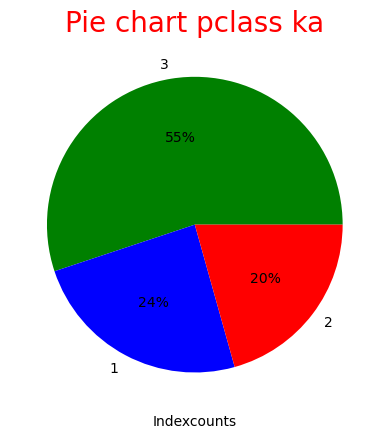

In [171]:
plt.title("Pie chart pclass ka", fontdict={"color":"r", "size":20})
plt.xlabel("Indexcounts")
plt.pie(x=data.pclass.value_counts(), labels=data.pclass.value_counts().index,autopct="%i%%", colors=["g","b","r"])
plt.show()